In [49]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

train_data_pl = pl.read_csv(r"../data/train.csv",encoding="shift_jis")

In [81]:
import importlib
import ml_pipeline
import mlflow

In [82]:
#リロード
importlib.reload(ml_pipeline)

/usr/local/lib/python3.11/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


<module 'ml_pipeline' from '/work/ml_pipeline.py'>

In [83]:
mlflow.set_tracking_uri("http://mlflow:5000")
mlflow.set_experiment("exp2")

<Experiment: artifact_location='/mlruns/1', creation_time=1775686978108, experiment_id='1', last_update_time=1775686978108, lifecycle_stage='active', name='exp2', tags={}, workspace='default'>

In [84]:
from ml_pipeline import MoisturePipeline, FullPipelineModel

pipe = MoisturePipeline(
    use_pca=False,
    use_diff=True,
    params={
        "verbosity": -1,
        "n_estimators": 10,
        "learning_rate": 0.05,
        "num_leaves": 64,
        "min_data_in_leaf": 5,
        "n_jobs": -1,
    }
)
rmse = pipe.fit(train_data_pl)

with mlflow.start_run():
    mlflow.log_params(pipe.params)
    #mlflow.log_param("pca_components", pipe.fe.pca.n_components)

    mlflow.log_metric("rmse", rmse)

    mlflow.pyfunc.log_model(
        name="model",
        python_model=FullPipelineModel(pipe)
    )

/usr/local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
2026/04/12 22:07:29 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


🏃 View run upset-croc-760 at: http://mlflow:5000/#/experiments/1/runs/05fb3d15a67c4e489719cf541cec36ac
🧪 View experiment at: http://mlflow:5000/#/experiments/1


### sharpray値を使い　2次微分は1,特定の特徴量だけが落としている　or 2.全体的に効いていない　をみる

In [85]:
#del
print(len(pipe.feature_cols))  
print(len(pipe.fe.feature_cols))

1555
1557


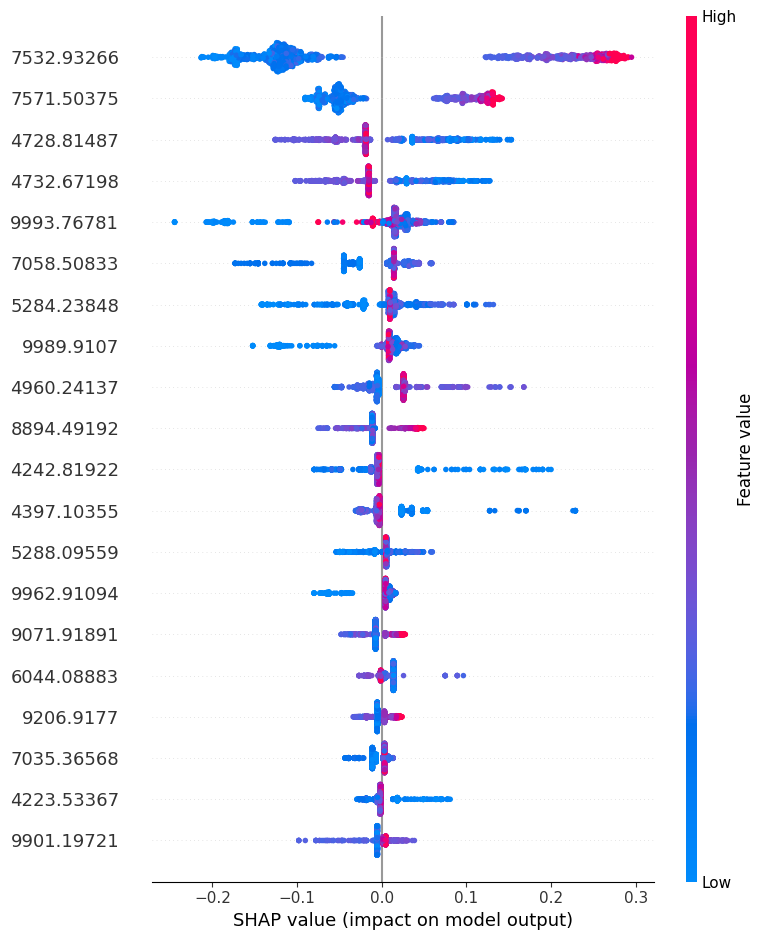


=== SHAP importance ===
7532.93266    0.158869
7571.50375    0.071263
4728.81487    0.051120
4732.67198    0.042188
9993.76781    0.037338
7058.50833    0.032578
5284.23848    0.028928
9989.9107     0.023572
4960.24137    0.020897
8894.49192    0.019335
4242.81922    0.019123
4397.10355    0.015833
5288.09559    0.012769
9962.91094    0.012707
9071.91891    0.012404
6044.08883    0.009596
9206.9177     0.009325
7035.36568    0.008114
4223.53367    0.007972
9901.19721    0.007769
dtype: float64


7532.93266    0.158869
7571.50375    0.071263
4728.81487    0.051120
4732.67198    0.042188
9993.76781    0.037338
                ...   
7864.64398    0.000000
7868.50109    0.000000
7872.3582     0.000000
7876.21531    0.000000
3999.82139    0.000000
Length: 1555, dtype: float64

In [86]:
from ml_pipeline import FeatureEngineer  # 定義している場所からimport

# SHAP可視化

pipe.fe.show_shap(train_data_pl, pipe.model, pipe.feature_cols)

#pipe.fe.show_shap(train_data_pl, pipe.model, pipe.feature_cols)

In [218]:
print(len(pipe.feature_cols))        # ← 1555
print(len(pipe.fe.feature_cols))     # ← 1557

1555
1557



## モデルを引き落としてきて実験する

In [75]:
import mlflow

experiment_name = "exp2"  # もしくはあなたの実験名

experiment = mlflow.get_experiment_by_name(experiment_name)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["start_time DESC"],
    max_results=1
)

latest_run_id = runs.iloc[0]["run_id"]
print(latest_run_id)

d1e10136841f4842b13694e6af97a4d5


In [76]:
model = mlflow.pyfunc.load_model(f"runs:/{latest_run_id}/model")

In [77]:
mlflow.pyfunc.log_model(
    name="model",
    python_model=FullPipelineModel(pipe)
)

2026/04/04 21:35:53 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


In [79]:
model

mlflow.pyfunc.loaded_model:
  artifact_path: /mlruns/5/models/m-278c1a7af9f2414f8926ccc85351266f/artifacts
  flavor: mlflow.pyfunc.model
  run_id: d1e10136841f4842b13694e6af97a4d5